## Methods Sensitivity Section


In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
import healpy as hp 

import matplotlib.pyplot as plt

In [3]:
%load_ext autoreload
%autoreload 2

from CHORD_Sensitivity import Telescope
from CHORD_Sensitivity.constants import K_B, OMEGA

chord = Telescope('CHORD')
pathfinder = Telescope('PATHFINDER')

output_dir = Path("noise_rms_plots")
output_dir.mkdir(parents=True, exist_ok=True)


In [4]:
freq_range = np.linspace(300, 1500, 13) # MHz
bandwidth_range = np.array([5, 20, 200]) # kHz

chord_rms = [chord.sigma_rms(freq=freq_range, delta_nu=bandwidth * 1e3) for bandwidth in bandwidth_range]
pathfinder_rms = [pathfinder.sigma_rms(freq=freq_range, delta_nu=bandwidth * 1e3) for bandwidth in bandwidth_range]

chord_df = pd.DataFrame(
    np.array(chord_rms).T * 1e3,  # Convert to mJy/beam
    index=freq_range,
    columns=bandwidth_range.astype(str) + ' kHz'
).rename_axis(index="Frequency", columns="Bandwidth")

pathfinder_df = pd.DataFrame(
    np.array(pathfinder_rms).T * 1e3,  # Convert to mJy/beam
    index=freq_range,
    columns=bandwidth_range.astype(str) + ' kHz'
).rename_axis(index="Frequency", columns="Bandwidth")

sigma_rms_df = pd.concat(
    {"CHORD": chord_df, "PATHFINDER": pathfinder_df},
    axis=1
)
sigma_rms_df.index.name = "Frequency (MHz)"
sigma_rms_df.columns.names = ["Telescope", "Bandwidth"]
sigma_rms_df

Telescope           CHORD                     PATHFINDER                     
Bandwidth           5 kHz    20 kHz   200 kHz      5 kHz     20 kHz   200 kHz
Frequency (MHz)                                                              
300.0            2.130266  1.065133  0.336825  17.156453   8.578227  2.712673
400.0            2.459820  1.229910  0.388932  19.810566   9.905283  3.132325
500.0            2.750162  1.375081  0.434839  22.148886  11.074443  3.502046
600.0            3.012651  1.506326  0.476342  24.262889  12.131444  3.836300
700.0            3.254035  1.627018  0.514508  26.206915  13.103457  4.143677
800.0            3.478710  1.739355  0.550032  28.016371  14.008185  4.429777
900.0            3.689729  1.844865  0.583397  29.715848  14.857924  4.698488
1000.0           3.889316  1.944658  0.614955  31.323254  15.661627  4.952641
1100.0           4.079149  2.039575  0.644970  32.852106  16.426053  5.194374
1200.0           4.260532  2.130266  0.673649  34.312906  17.156453  5.425347
1300.0           4.434503  2.217251  0.701156  35.714005  17.857003  5.646880
1400.0           4.601901  2.300951  0.727624  37.062175  18.531087  5.860044
1500.0           4.763420  2.381710  0.753163  38.362995  19.181498  6.065722

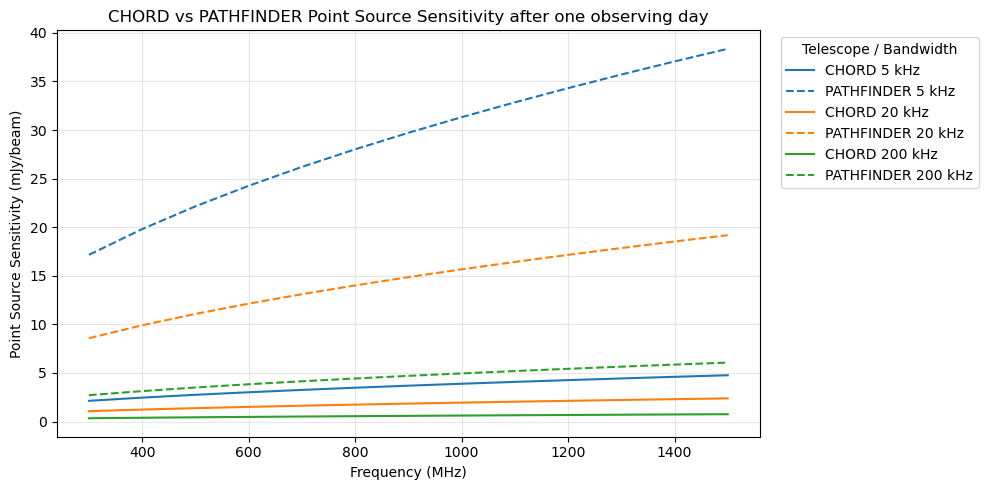

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

bw_labels = [f"{bw} kHz" for bw in bandwidth_range]
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for i, bw in enumerate(bw_labels):
    c = colors[i % len(colors)]
    ax.plot(
        sigma_rms_df.index,
        sigma_rms_df[("CHORD", bw)],
        color=c,
        # marker="o",
        linestyle="-",
        label=f"CHORD {bw}",
    )
    ax.plot(
        sigma_rms_df.index,
        sigma_rms_df[("PATHFINDER", bw)],
        color=c,
        # marker="o",
        linestyle="--",
        label=f"PATHFINDER {bw}",
    )

ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Point Source Sensitivity (mJy/beam)")
ax.set_title("CHORD vs PATHFINDER Point Source Sensitivity after one observing day")
ax.grid(True, alpha=0.3)
ax.legend(title="Telescope / Bandwidth", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

fig.savefig(output_dir / "chord_vs_pathfinder_point_source_sensitivity.png", dpi=300, bbox_inches="tight")

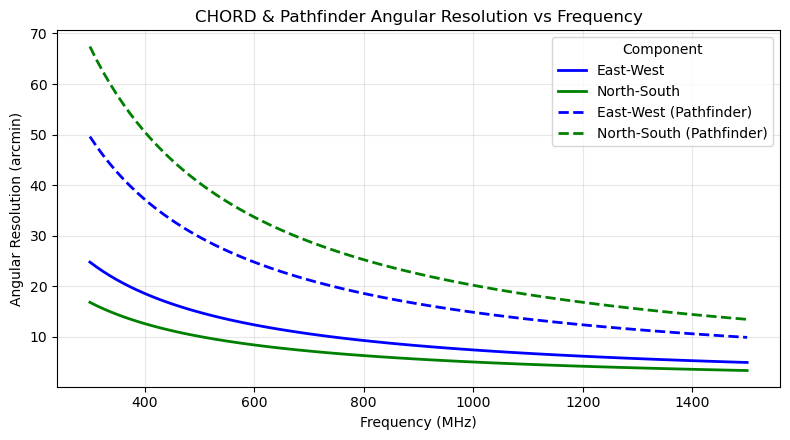

In [6]:
freq = np.linspace(300, 1500, 100)  # MHz
chord_s_fwhm = chord.S_FWHM(freq)
pathfinder_s_fwhm = pathfinder.S_FWHM(freq)

rad_to_arcmin = (180 / np.pi) * 60
chord_s_fwhm = [(ew * rad_to_arcmin, ns * rad_to_arcmin) for ew, ns in chord_s_fwhm]
pathfinder_s_fwhm = [(ew * rad_to_arcmin, ns * rad_to_arcmin) for ew, ns in pathfinder_s_fwhm]
c_ew_fwhm = [fwhm[0] for fwhm in chord_s_fwhm]
c_ns_fwhm = [fwhm[1] for fwhm in chord_s_fwhm]
p_ew_fwhm = [fwhm[0] for fwhm in pathfinder_s_fwhm]
p_ns_fwhm = [fwhm[1] for fwhm in pathfinder_s_fwhm]
chord_s_fwhm_df = pd.DataFrame({"Frequency (MHz)": freq, "EW_FWHM": c_ew_fwhm, "NS_FWHM": c_ns_fwhm})
pathfinder_s_fwhm_df = pd.DataFrame({"Frequency (MHz)": freq, "EW_FWHM": p_ew_fwhm, "NS_FWHM": p_ns_fwhm})

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(chord_s_fwhm_df["Frequency (MHz)"], chord_s_fwhm_df["EW_FWHM"], c='blue', label="East-West", linewidth=2)
ax.plot(chord_s_fwhm_df["Frequency (MHz)"], chord_s_fwhm_df["NS_FWHM"], c='green', label="North-South", linewidth=2)

ax.plot(pathfinder_s_fwhm_df["Frequency (MHz)"], pathfinder_s_fwhm_df["EW_FWHM"], c='blue', label="East-West (Pathfinder)", linestyle="--", linewidth=2)
ax.plot(pathfinder_s_fwhm_df["Frequency (MHz)"], pathfinder_s_fwhm_df["NS_FWHM"], c='green', label="North-South (Pathfinder)", linestyle="--", linewidth=2)

ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Angular Resolution (arcmin)")
ax.set_title("CHORD & Pathfinder Angular Resolution vs Frequency")
ax.grid(True, alpha=0.3)
ax.legend(title="Component")

plt.tight_layout()

plt.savefig(output_dir / "chord_pathfinder_angular_resolution.png", dpi=300, bbox_inches="tight")


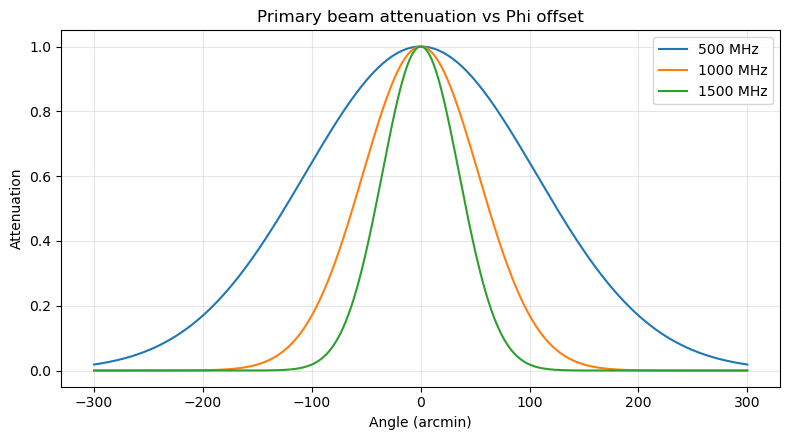

In [7]:
arcmins = np.linspace(-300, 300, 500)
arcmins_rad = np.deg2rad(arcmins / 60)

fig, ax = plt.subplots(figsize=(8, 4.5))
for freq in [500, 1000, 1500]:  # MHz
    freq_range = [freq] * len(arcmins_rad)
    phi_offset = chord.D_phi(phi_offset=arcmins_rad, freq=freq_range)
    ax.plot(arcmins, phi_offset, label=f"{freq} MHz")
ax.set_xlabel("Angle (arcmin)")
ax.set_ylabel("Attenuation")
ax.set_title("Primary beam attenuation vs Phi offset")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(output_dir / "chord_primary_beam_attenuation.png", dpi=300, bbox_inches="tight")

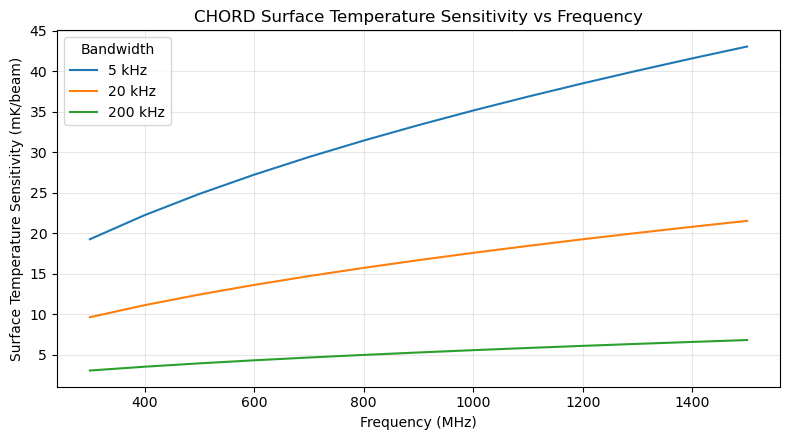

In [8]:
freq_range = np.linspace(300, 1500, 13) # MHz
bandwidth_range = np.array([5, 20, 200]) # kHz

chord_sensitivity = [
    chord.surface_temperature(
        freq=freq_range,
        sigma_rms=chord.sigma_rms(freq=freq_range, delta_nu=bandwidth * 1e3),
        delta_nu=bandwidth * 1e3
    )
    for bandwidth in bandwidth_range]

sensitivity_df = pd.DataFrame(
    np.array(chord_sensitivity).T * 1e3,  # Convert to mK/beam
    index=freq_range,
    columns=bandwidth_range.astype(str) + ' kHz'
).rename_axis(index="Frequency", columns="Bandwidth")
fig, ax = plt.subplots(figsize=(8, 4.5))

for bw in sensitivity_df.columns:
    ax.plot(sensitivity_df.index, sensitivity_df[bw], label=bw)

ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Surface Temperature Sensitivity (mK/beam)")
ax.set_title("CHORD Surface Temperature Sensitivity vs Frequency")
ax.grid(True, alpha=0.3)
ax.legend(title="Bandwidth")

plt.tight_layout()

fig.savefig(output_dir / "chord_surface_temperature_sensitivity.png", dpi=300, bbox_inches="tight")

/var/folders/1v/pf54418j6fj5541rk7ynqhgw0000gn/T/ipykernel_8707/2680363510.py:34: RuntimeWarning: All-NaN axis encountered
  hp_map = np.nanmin(maps, axis=0)


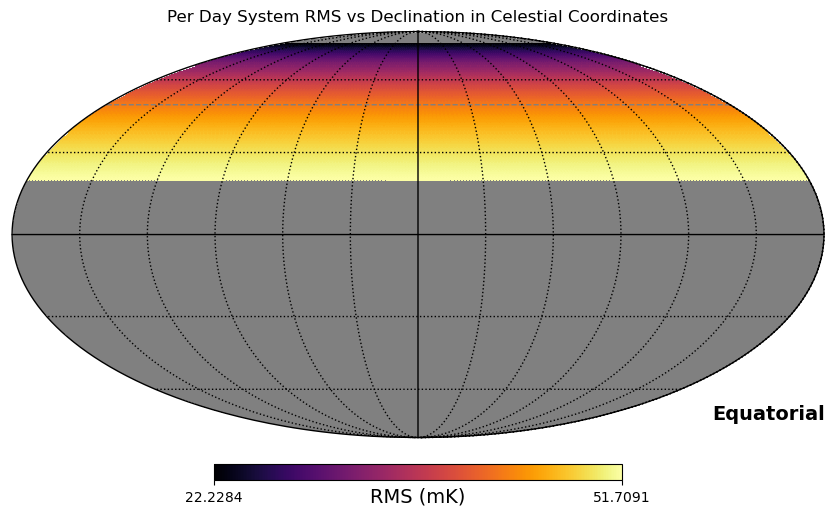

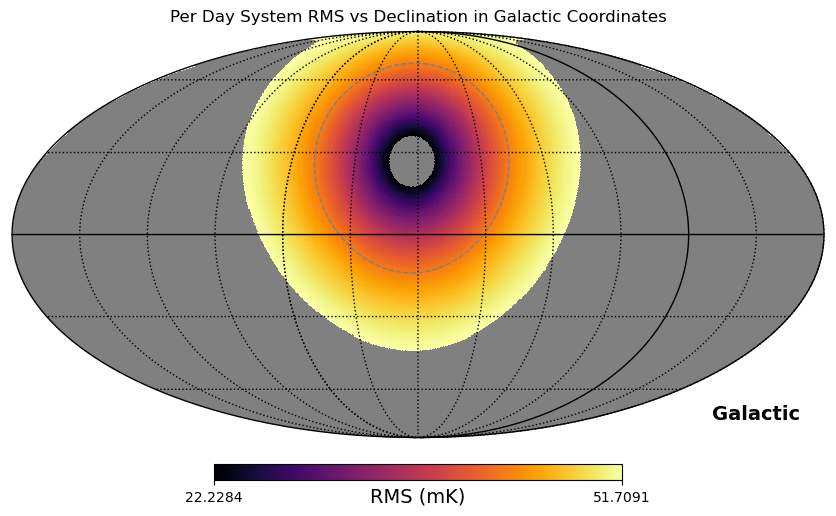

In [12]:
# Define the latitude (declination for zenith pointing)
CHORD_angles = np.linspace(20, 80, 100)  # degrees North
dec = 49
bandwidth = 5*1e3  # kHz

# Calculate the colatitude theta in radians (theta = 90° - declination)
theta_target = np.deg2rad(90 - CHORD_angles)
dec_center = np.deg2rad(90 - dec)

# Generate azimuthal angles phi from 0 to 2π for dense sampling to cover pixels
phi = np.linspace(0, 2 * np.pi, 10000)  # High density for better pixel coverage

# Choose a higher NSIDE for better resolution of the thin arc
nside = 128  # Increased from 16 for finer detail; adjust as needed

# Convert theta and phi to pixel indices and set those pixels to 0.5
# Use unique pixels to avoid overwriting
maps = []
ref_freq = 1.5e9  # Reference frequency for surface temperature calculation
for n in range(len(theta_target)):
    pointing_angle_deg = CHORD_angles[n]
    theta = theta_target[n]
    hp_map = np.full(hp.nside2npix(nside), np.nan)
    pixels = hp.ang2pix(nside, theta * np.ones_like(phi), phi)
    unique_pixels = np.unique(pixels)
    hp_map[unique_pixels] = chord.surface_temperature(
        freq=ref_freq,
        sigma_rms=chord.sigma_rms(freq=ref_freq, delta_nu=bandwidth, dec_deg=pointing_angle_deg),
        delta_nu=bandwidth
    )*1e3
    maps.append(hp_map)

# Combine all maps into a single HEALPix map
hp_map = np.nanmin(maps, axis=0)

hp_map[hp_map == 0] = np.nan  # Set non-arc pixels to NaN for better visualization

# First plot: Celestial coordinates
hp.mollview(hp_map, title='Per Day System RMS vs Declination in Celestial Coordinates',
            cmap='inferno', unit='RMS (mK)', coord='C', min=np.nanmin(hp_map), max=np.nanmax(hp_map))
hp.projplot(dec_center * np.ones_like(phi), phi, lw=1, color='grey', linestyle='dashed', coord='C')
hp.graticule()
plt.savefig(output_dir / "RMS_declination_map_celestial.png", dpi=300, bbox_inches="tight")
plt.show()

# Second plot: Galactic coordinates
hp.mollview(hp_map, title='Per Day System RMS vs Declination in Galactic Coordinates',
            cmap='inferno', unit='RMS (mK)', coord=['C', 'G'], rot=(120, 0))
hp.projplot(dec_center * np.ones_like(phi), phi, lw=1, color='grey', linestyle='dashed', coord='C')
hp.graticule()
plt.savefig(output_dir / "RMS_declination_map_galactic.png", dpi=300, bbox_inches="tight")
plt.show()

# Radio Background